# Exploratory Analysis of 30-Day Hospital Readmission

This notebook examines the distribution of 30-day readmission and its observed relationships with patient demographics, hospitalization characteristics, prior healthcare utilization, laboratory testing, and treatment.

The results describe unadjusted associations and do not establish causation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

VILLANOVA_NAVY = "#00205B"
LIGHT_BLUE = "#5BC2E7"
GRAY = "#6B7280"

In [2]:
project_root = Path.cwd()

if not (project_root / "data").exists():
    project_root = project_root.parent

clean_data_path = (
    project_root
    / "data"
    / "processed"
    / "hospital_readmissions_clean.csv"
)

figures_path = project_root / "reports" / "figures"
tables_path = project_root / "reports" / "tables"

figures_path.mkdir(parents=True, exist_ok=True)
tables_path.mkdir(parents=True, exist_ok=True)

encounters = pd.read_csv(clean_data_path, low_memory=False)

print("Dataset shape:", encounters.shape)
print("Unique patients:", encounters["patient_nbr"].nunique())
print(
    "30-day readmission rate:",
    f"{encounters['readmitted_30d'].mean() * 100:.2f}%"
)

encounters.head()

Dataset shape: (99340, 54)
Unique patients: 69987
30-day readmission rate: 11.39%


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,medication_change,diabetes_medication,readmitted,readmitted_30d,diag_1_group,diag_2_group,diag_3_group,admission_type,discharge_disposition,admission_source
0,12522,48330783,Caucasian,Female,[80-90),2,1,4,13,68,...,Ch,Yes,NO,0,Circulatory,Circulatory,Other,Urgent,Discharged to home,Transfer from a hospital
1,15738,63555939,Caucasian,Female,[90-100),3,3,4,12,33,...,Ch,Yes,NO,0,Circulatory,Neoplasms,Respiratory,Elective,Discharged/transferred to SNF,Transfer from a hospital
2,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,Ch,Yes,NO,0,Neoplasms,Neoplasms,Diabetes,Emergency,Discharged to home,Emergency Room
3,28236,89869032,AfricanAmerican,Female,[40-50),1,1,7,9,47,...,No,Yes,>30,0,Diabetes,Circulatory,Injury,Emergency,Discharged to home,Emergency Room
4,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,Yes,>30,0,Circulatory,Circulatory,Diabetes,Urgent,Discharged to home,Clinic Referral


In [3]:
def readmission_summary(data, group_column):
    """Calculate encounter counts and readmission rates by group."""

    summary = (
        data.groupby(group_column, dropna=False)
        .agg(
            encounters=("encounter_id", "count"),
            readmissions=("readmitted_30d", "sum"),
            readmission_rate=("readmitted_30d", "mean")
        )
        .reset_index()
    )

    summary["readmission_rate_pct"] = (
        summary["readmission_rate"] * 100
    ).round(2)

    return summary

In [4]:
target_summary = (
    encounters["readmitted_30d"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Not readmitted within 30 days",
        1: "Readmitted within 30 days"
    })
    .rename_axis("outcome")
    .reset_index(name="encounters")
)

target_summary["percentage"] = (
    target_summary["encounters"]
    / len(encounters)
    * 100
).round(2)

target_summary.to_csv(
    tables_path / "target_distribution.csv",
    index=False
)

target_summary

,outcome,encounters,percentage
0,Not readmitted within 30 days,88026,88.61
1,Readmitted within 30 days,11314,11.39


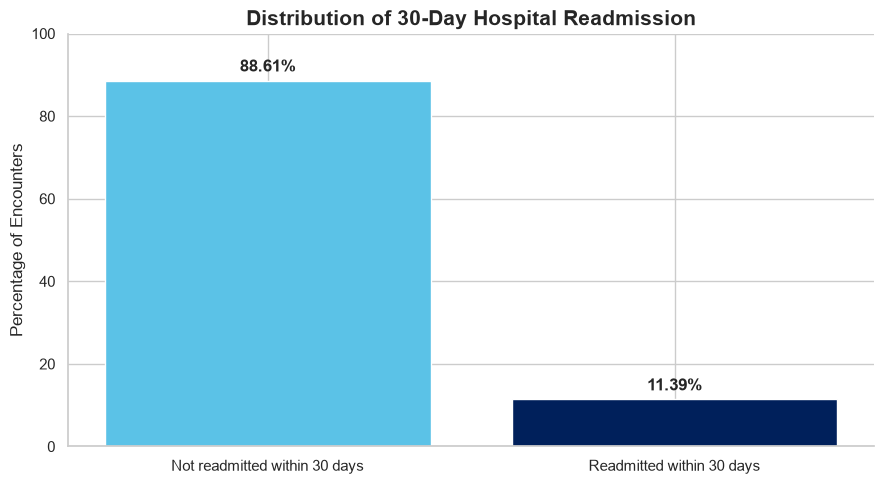

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    target_summary["outcome"],
    target_summary["percentage"],
    color=[LIGHT_BLUE, VILLANOVA_NAVY]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in target_summary["percentage"]
    ],
    padding=4,
    fontweight="bold"
)

ax.set_title(
    "Distribution of 30-Day Hospital Readmission",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("")
ax.set_ylabel("Percentage of Encounters")
ax.set_ylim(0, 100)

sns.despine()
plt.tight_layout()

plt.savefig(
    figures_path / "target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
age_summary = readmission_summary(encounters, "age")
race_summary = readmission_summary(encounters, "race")
gender_summary = readmission_summary(encounters, "gender")

age_summary.to_csv(
    tables_path / "readmission_by_age.csv",
    index=False
)
race_summary.to_csv(
    tables_path / "readmission_by_race.csv",
    index=False
)
gender_summary.to_csv(
    tables_path / "readmission_by_gender.csv",
    index=False
)

display(age_summary)
display(
    race_summary.sort_values(
        "readmission_rate_pct",
        ascending=False
    )
)
display(gender_summary)

,age,encounters,readmissions,readmission_rate,readmission_rate_pct
0,[0-10),160,3,0.018750,1.88
1,[10-20),690,40,0.057971,5.80
2,[20-30),1649,236,0.143117,14.31
3,[30-40),3764,424,0.112646,11.26
4,[40-50),9607,1024,0.106589,10.66
5,[50-60),17060,1667,0.097714,9.77
6,[60-70),22058,2493,0.113020,11.30
7,[70-80),25329,3054,0.120573,12.06
8,[80-90),16434,2065,0.125654,12.57
9,[90-100),2589,308,0.118965,11.90


,race,encounters,readmissions,readmission_rate,readmission_rate_pct
2,Caucasian,74220,8556,0.115279,11.53
0,AfricanAmerican,18772,2149,0.114479,11.45
3,Hispanic,2017,212,0.105107,10.51
1,Asian,628,65,0.103503,10.35
4,Other,1471,144,0.097893,9.79
5,NaN,2232,188,0.084229,8.42


,gender,encounters,readmissions,readmission_rate,readmission_rate_pct
0,Female,53454,6128,0.114641,11.46
1,Male,45886,5186,0.113019,11.30


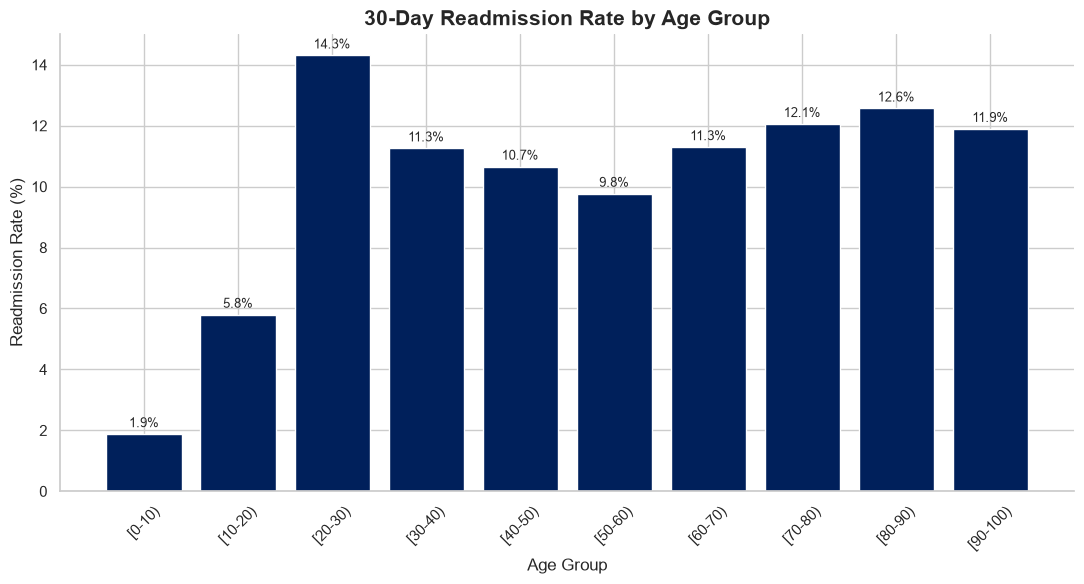

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    age_summary["age"],
    age_summary["readmission_rate_pct"],
    color=VILLANOVA_NAVY
)

ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}%"
        for rate in age_summary["readmission_rate_pct"]
    ],
    padding=3,
    fontsize=9
)

ax.set_title(
    "30-Day Readmission Rate by Age Group",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Age Group")
ax.set_ylabel("Readmission Rate (%)")
ax.tick_params(axis="x", rotation=45)

sns.despine()
plt.tight_layout()

plt.savefig(
    figures_path / "readmission_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

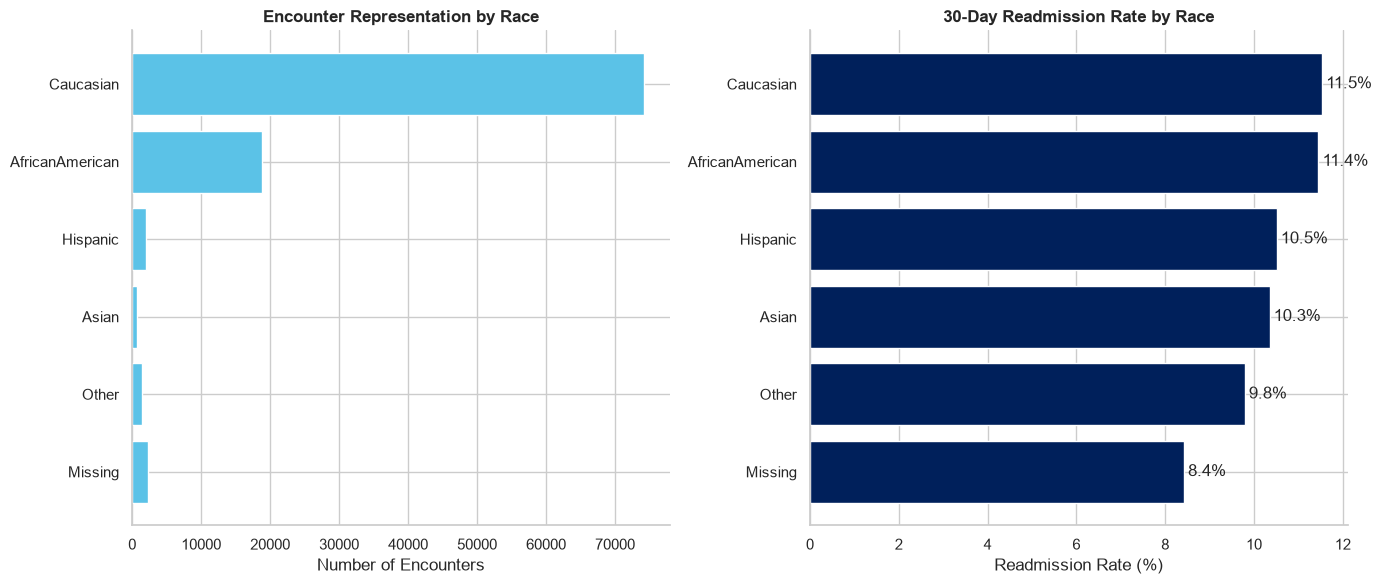

In [8]:
race_display = encounters.copy()
race_display["race"] = race_display["race"].fillna("Missing")

race_summary = readmission_summary(race_display, "race")
race_summary = race_summary.sort_values(
    "readmission_rate_pct",
    ascending=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(
    race_summary["race"],
    race_summary["encounters"],
    color=LIGHT_BLUE
)
axes[0].set_title(
    "Encounter Representation by Race",
    fontweight="bold"
)
axes[0].set_xlabel("Number of Encounters")
axes[0].set_ylabel("")

bars = axes[1].barh(
    race_summary["race"],
    race_summary["readmission_rate_pct"],
    color=VILLANOVA_NAVY
)
axes[1].bar_label(
    bars,
    labels=[
        f"{rate:.1f}%"
        for rate in race_summary["readmission_rate_pct"]
    ],
    padding=3
)
axes[1].set_title(
    "30-Day Readmission Rate by Race",
    fontweight="bold"
)
axes[1].set_xlabel("Readmission Rate (%)")
axes[1].set_ylabel("")

sns.despine()
plt.tight_layout()

plt.savefig(
    figures_path / "race_representation_and_readmission.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

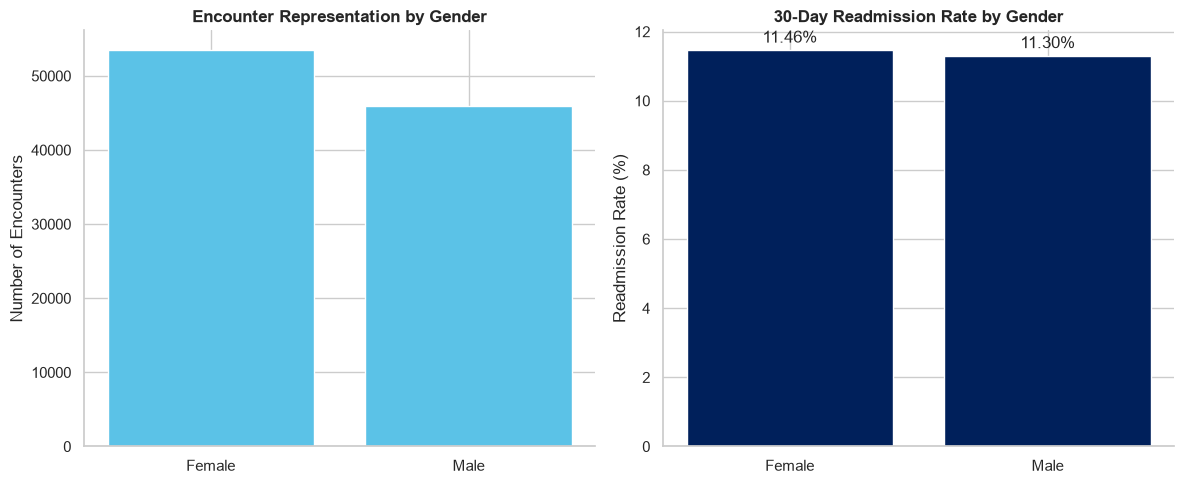

In [9]:
gender_summary = readmission_summary(encounters, "gender")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    gender_summary["gender"],
    gender_summary["encounters"],
    color=LIGHT_BLUE
)
axes[0].set_title(
    "Encounter Representation by Gender",
    fontweight="bold"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Encounters")

gender_bars = axes[1].bar(
    gender_summary["gender"],
    gender_summary["readmission_rate_pct"],
    color=VILLANOVA_NAVY
)
axes[1].bar_label(
    gender_bars,
    labels=[
        f"{rate:.2f}%"
        for rate in gender_summary["readmission_rate_pct"]
    ],
    padding=3
)
axes[1].set_title(
    "30-Day Readmission Rate by Gender",
    fontweight="bold"
)
axes[1].set_xlabel("")
axes[1].set_ylabel("Readmission Rate (%)")

sns.despine()
plt.tight_layout()

plt.savefig(
    figures_path / "gender_representation_and_readmission.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
utilization_fields = [
    "time_in_hospital",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

utilization_summary = encounters[
    utilization_fields + ["readmitted_30d"]
].groupby("readmitted_30d").agg(["mean", "median"]).round(2)

utilization_summary.to_csv(
    tables_path / "utilization_by_readmission.csv"
)

utilization_summary

time_in_hospital        number_outpatient         \
                           mean median              mean median   
readmitted_30d                                                    
0                          4.33    4.0              0.36    0.0   
1                          4.77    4.0              0.44    0.0   

               number_emergency        number_inpatient         
                           mean median             mean median  
readmitted_30d                                                  
0                          0.18    0.0             0.55    0.0  
1                          0.36    0.0             1.22    0.0

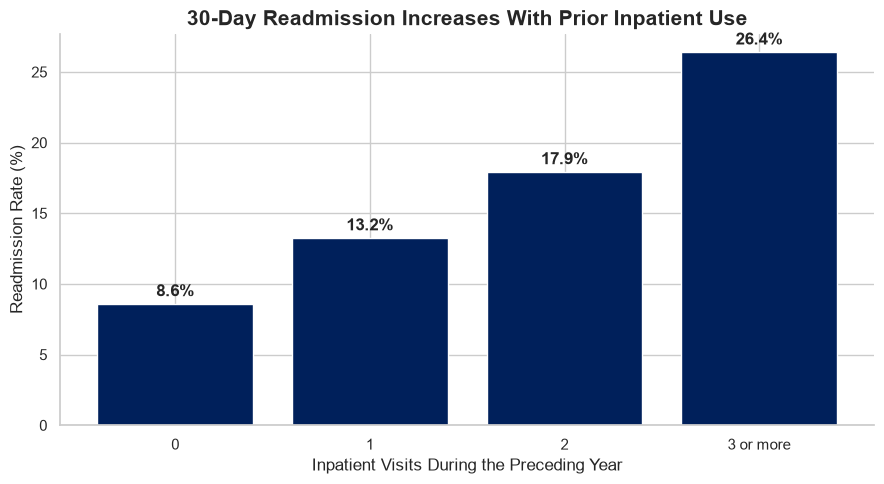

In [11]:
encounters["previous_inpatient_group"] = pd.cut(
    encounters["number_inpatient"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3 or more"]
)

inpatient_summary = readmission_summary(
    encounters,
    "previous_inpatient_group"
)

inpatient_summary.to_csv(
    tables_path / "readmission_by_previous_inpatient_visits.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    inpatient_summary["previous_inpatient_group"].astype(str),
    inpatient_summary["readmission_rate_pct"],
    color=VILLANOVA_NAVY
)

ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}%"
        for rate in inpatient_summary["readmission_rate_pct"]
    ],
    padding=3,
    fontweight="bold"
)

ax.set_title(
    "30-Day Readmission Increases With Prior Inpatient Use",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Inpatient Visits During the Preceding Year")
ax.set_ylabel("Readmission Rate (%)")

sns.despine()
plt.tight_layout()

plt.savefig(
    figures_path / "readmission_by_previous_inpatient_visits.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
clinical_fields = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

clinical_summary = (
    encounters
    .groupby("readmitted_30d")[clinical_fields]
    .agg(["mean", "median", "std"])
    .round(2)
)

clinical_summary.to_csv(
    tables_path / "clinical_characteristics_by_readmission.csv"
)

clinical_summary

time_in_hospital              num_lab_procedures                \
                           mean median   std               mean median    std   
readmitted_30d                                                                  
0                          4.33    4.0  2.96              42.74   44.0  19.65   
1                          4.77    4.0  3.03              44.22   45.0  19.27   

               num_procedures              num_medications               \
                         mean median   std            mean median   std   
readmitted_30d                                                            
0                        1.34    1.0  1.71           15.86   15.0  8.09   
1                        1.28    1.0  1.64           16.91   16.0  8.10   

               number_diagnoses               
                           mean median   std  
readmitted_30d                                
0                          7.36    8.0  1.96  
1                          7.69    9.0  1.77

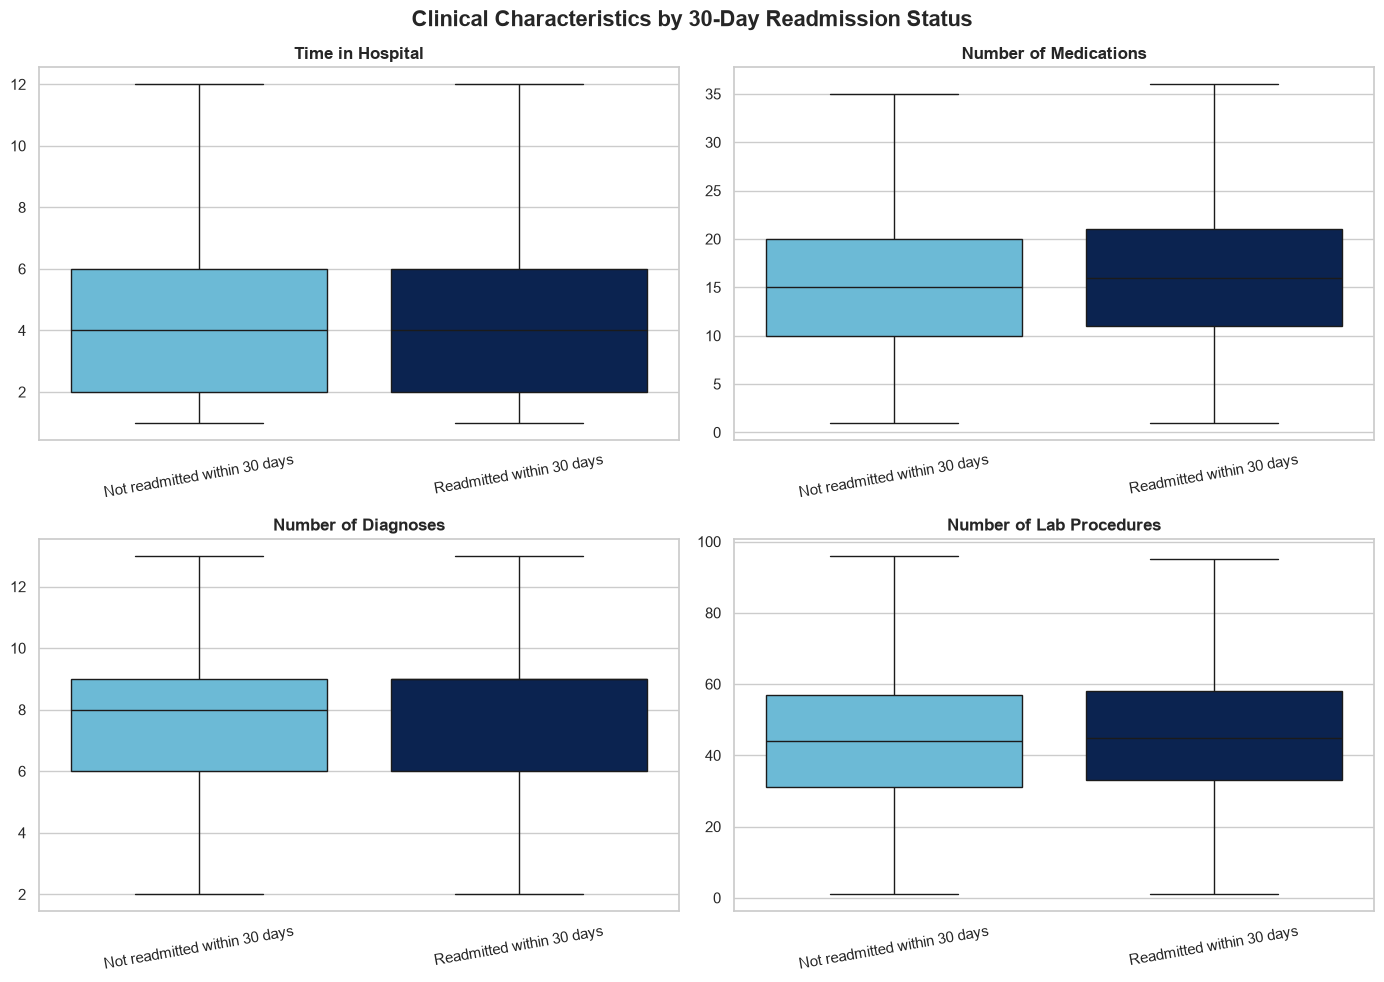

In [13]:
plot_data = encounters.copy()
plot_data["outcome"] = plot_data["readmitted_30d"].map({
    0: "Not readmitted within 30 days",
    1: "Readmitted within 30 days"
})

boxplot_fields = [
    ("time_in_hospital", "Time in Hospital"),
    ("num_medications", "Number of Medications"),
    ("number_diagnoses", "Number of Diagnoses"),
    ("num_lab_procedures", "Number of Lab Procedures")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (column, title) in zip(axes.flat, boxplot_fields):
    sns.boxplot(
        data=plot_data,
        x="outcome",
        y=column,
        hue="outcome",
        palette=[LIGHT_BLUE, VILLANOVA_NAVY],
        legend=False,
        showfliers=False,
        ax=ax
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=10)

plt.suptitle(
    "Clinical Characteristics by 30-Day Readmission Status",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()

plt.savefig(
    figures_path / "clinical_characteristics_by_readmission.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
a1c_summary = readmission_summary(encounters, "A1Cresult")
glucose_summary = readmission_summary(encounters, "max_glu_serum")
change_summary = readmission_summary(
    encounters,
    "medication_change"
)
diabetes_med_summary = readmission_summary(
    encounters,
    "diabetes_medication"
)

a1c_summary.to_csv(
    tables_path / "readmission_by_a1c_result.csv",
    index=False
)
glucose_summary.to_csv(
    tables_path / "readmission_by_glucose_result.csv",
    index=False
)
change_summary.to_csv(
    tables_path / "readmission_by_medication_change.csv",
    index=False
)
diabetes_med_summary.to_csv(
    tables_path / "readmission_by_diabetes_medication.csv",
    index=False
)

display(a1c_summary)
display(glucose_summary)
display(change_summary)
display(diabetes_med_summary)

,A1Cresult,encounters,readmissions,readmission_rate,readmission_rate_pct
0,>7,3775,383,0.101457,10.15
1,>8,8137,809,0.099422,9.94
2,Norm,4922,481,0.097725,9.77
3,NaN,82506,9641,0.116852,11.69


,max_glu_serum,encounters,readmissions,readmission_rate,readmission_rate_pct
0,>200,1419,184,0.129669,12.97
1,>300,1188,179,0.150673,15.07
2,Norm,2545,294,0.115521,11.55
3,NaN,94188,10657,0.113146,11.31


,medication_change,encounters,readmissions,readmission_rate,readmission_rate_pct
0,Ch,46120,5545,0.120230,12.02
1,No,53220,5769,0.108399,10.84


,diabetes_medication,encounters,readmissions,readmission_rate,readmission_rate_pct
0,No,22623,2233,0.098705,9.87
1,Yes,76717,9081,0.118370,11.84


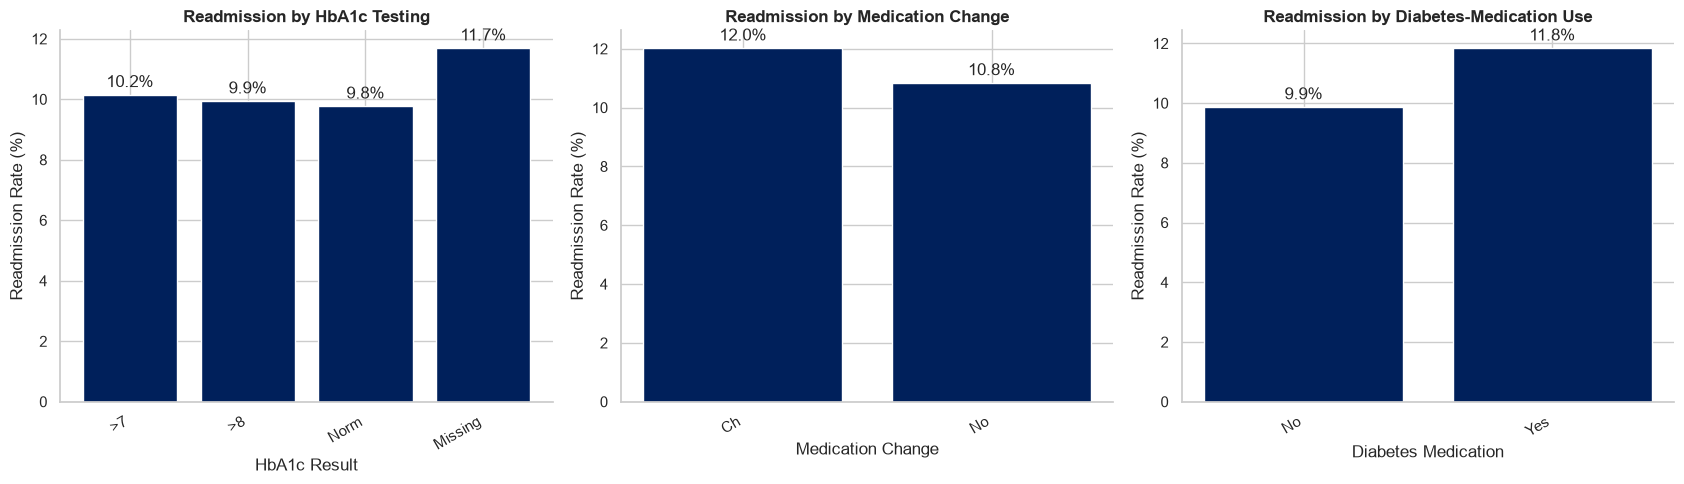

In [16]:
testing_treatment_summaries = [
    (
        a1c_summary,
        "A1Cresult",
        "HbA1c Result",
        "Readmission by HbA1c Testing"
    ),
    (
        change_summary,
        "medication_change",
        "Medication Change",
        "Readmission by Medication Change"
    ),
    (
        diabetes_med_summary,
        "diabetes_medication",
        "Diabetes Medication",
        "Readmission by Diabetes-Medication Use"
    )
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (summary, column, x_label, title) in zip(
    axes,
    testing_treatment_summaries
):
    labels = (
        summary[column]
        .fillna("Missing")
        .astype("string")
        .fillna("Missing")
        .tolist()
    )

    rates = pd.to_numeric(
        summary["readmission_rate_pct"]
    ).to_numpy()

    positions = np.arange(len(labels))

    bars = ax.bar(
        positions,
        rates,
        color=VILLANOVA_NAVY
    )

    ax.set_xticks(
        positions,
        labels,
        rotation=30,
        ha="right"
    )

    ax.bar_label(
        bars,
        labels=[
            f"{rate:.1f}%"
            for rate in rates
        ],
        padding=3
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Readmission Rate (%)")

sns.despine()
plt.tight_layout()

plt.savefig(
    figures_path / "testing_and_treatment_readmission.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

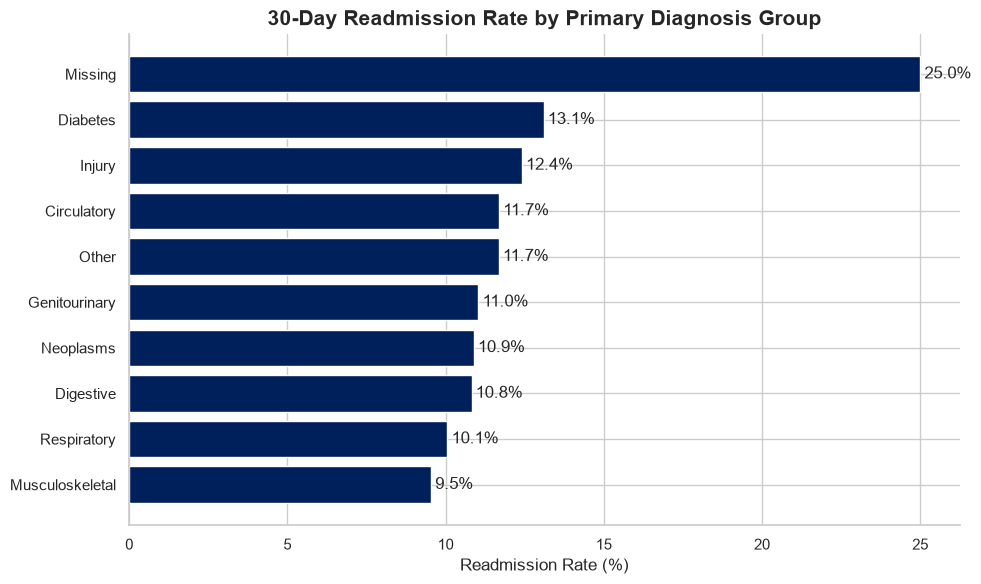

,diag_1_group,encounters,readmissions,readmission_rate,readmission_rate_pct
6,Musculoskeletal,4935,471,0.095441,9.54
9,Respiratory,13934,1402,0.100617,10.06
2,Digestive,9333,1010,0.108218,10.82
7,Neoplasms,3131,341,0.108911,10.89
3,Genitourinary,5002,552,0.110356,11.04
8,Other,17793,2079,0.116844,11.68
0,Circulatory,29680,3469,0.116880,11.69
4,Injury,6851,850,0.124069,12.41
1,Diabetes,8661,1135,0.131047,13.10
5,Missing,20,5,0.250000,25.00


In [17]:
diagnosis_summary = readmission_summary(
    encounters,
    "diag_1_group"
).sort_values(
    "readmission_rate_pct",
    ascending=True
)

diagnosis_summary.to_csv(
    tables_path / "readmission_by_primary_diagnosis.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    diagnosis_summary["diag_1_group"],
    diagnosis_summary["readmission_rate_pct"],
    color=VILLANOVA_NAVY
)

ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}%"
        for rate in diagnosis_summary["readmission_rate_pct"]
    ],
    padding=3
)

ax.set_title(
    "30-Day Readmission Rate by Primary Diagnosis Group",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Readmission Rate (%)")
ax.set_ylabel("")

sns.despine()
plt.tight_layout()

plt.savefig(
    figures_path / "readmission_by_primary_diagnosis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

diagnosis_summary

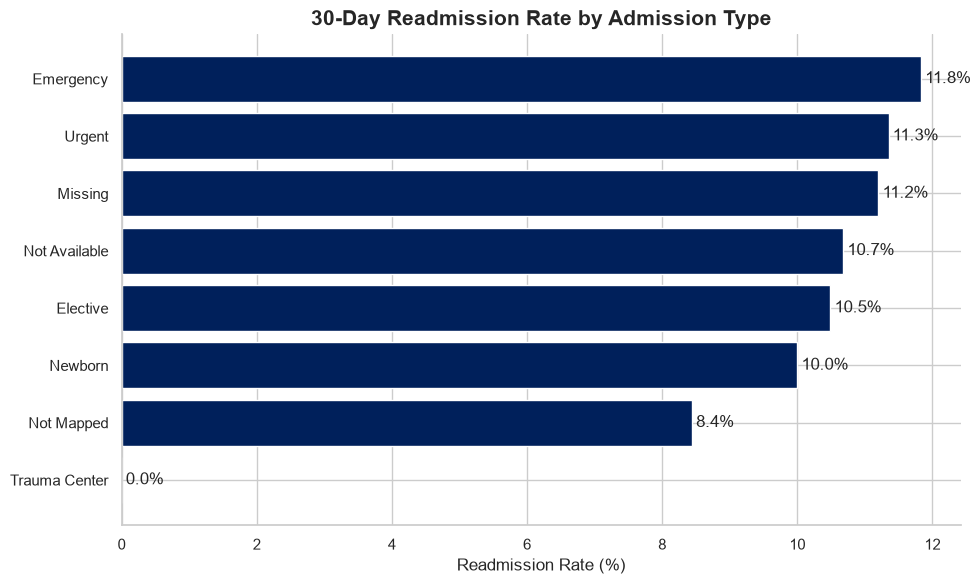

,admission_type,encounters,readmissions,readmission_rate,readmission_rate_pct
6,Trauma Center,18,0,0.000000,0.00
5,Not Mapped,320,27,0.084375,8.44
3,Newborn,10,1,0.100000,10.00
0,Elective,18667,1958,0.104891,10.49
4,Not Available,4617,493,0.106779,10.68
2,Missing,5207,583,0.111965,11.20
7,Urgent,18132,2058,0.113501,11.35
1,Emergency,52369,6194,0.118276,11.83


In [18]:
admission_data = encounters.copy()
admission_data["admission_type"] = (
    admission_data["admission_type"]
    .replace("NULL", "Missing")
    .fillna("Missing")
)

admission_summary = readmission_summary(
    admission_data,
    "admission_type"
).sort_values(
    "readmission_rate_pct",
    ascending=True
)

admission_summary.to_csv(
    tables_path / "readmission_by_admission_type.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    admission_summary["admission_type"],
    admission_summary["readmission_rate_pct"],
    color=VILLANOVA_NAVY
)

ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}%"
        for rate in admission_summary["readmission_rate_pct"]
    ],
    padding=3
)

ax.set_title(
    "30-Day Readmission Rate by Admission Type",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Readmission Rate (%)")
ax.set_ylabel("")

sns.despine()
plt.tight_layout()

plt.savefig(
    figures_path / "readmission_by_admission_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

admission_summary

In [19]:
def highest_rate_group(summary, group_column, minimum_encounters=1):
    eligible = summary[
        summary["encounters"] >= minimum_encounters
    ]

    highest = eligible.loc[
        eligible["readmission_rate_pct"].idxmax()
    ]

    return {
        "group": highest[group_column],
        "encounters": int(highest["encounters"]),
        "rate": float(highest["readmission_rate_pct"])
    }


overall_rate = round(
    encounters["readmitted_30d"].mean() * 100,
    2
)

key_results = {
    "Overall readmission rate": {
        "group": "All eligible encounters",
        "encounters": len(encounters),
        "rate": overall_rate
    },
    "Highest age-group rate": highest_rate_group(
        age_summary,
        "age",
        minimum_encounters=500
    ),
    "Highest race-group rate": highest_rate_group(
        race_summary,
        "race",
        minimum_encounters=500
    ),
    "Highest prior-inpatient rate": highest_rate_group(
        inpatient_summary,
        "previous_inpatient_group",
        minimum_encounters=500
    ),
    "Highest primary-diagnosis rate": highest_rate_group(
        diagnosis_summary,
        "diag_1_group",
        minimum_encounters=500
    ),
    "Highest admission-type rate": highest_rate_group(
        admission_summary,
        "admission_type",
        minimum_encounters=500
    )
}

key_results_df = (
    pd.DataFrame(key_results)
    .T
    .reset_index()
    .rename(columns={"index": "finding"})
)

key_results_df.to_csv(
    tables_path / "key_eda_results.csv",
    index=False
)

key_results_df

,finding,group,encounters,rate
0,Overall readmission rate,All eligible encounters,99340,11.39
1,Highest age-group rate,[20-30),1649,14.31
2,Highest race-group rate,Caucasian,74220,11.53
3,Highest prior-inpatient rate,3 or more,6814,26.4
4,Highest primary-diagnosis rate,Diabetes,8661,13.1
5,Highest admission-type rate,Emergency,52369,11.83


## Key findings

- The overall 30-day readmission rate was **11.39%** among the 99,340 eligible encounters.
- Prior inpatient utilization showed the strongest descriptive pattern. Encounters involving patients with **three or more inpatient visits during the preceding year** had a 30-day readmission rate of **26.4%**.
- Among age groups with at least 500 encounters, patients ages **20–29** had the highest observed readmission rate at **14.31%**.
- Among recorded racial groups with at least 500 encounters, **Caucasian patients** had the highest observed rate at **11.53%**. Differences by race should be interpreted cautiously because the groups differ substantially in size and representation.
- Encounters with a primary diagnosis categorized as **diabetes** had the highest diagnosis-group rate at **13.1%**.
- **Emergency admissions** had the highest observed admission-type rate among categories with at least 500 encounters, at **11.83%**.

For comparisons identifying the highest group rate, categories with fewer than 500 encounters were excluded to reduce the influence of unstable estimates from small groups. These are unadjusted descriptive comparisons.

## Interpretation

These exploratory results describe unadjusted relationships between recorded encounter characteristics and 30-day readmission. Differences between groups may reflect variation in health status, previous healthcare utilization, access to follow-up care, hospital practices, and other measured or unmeasured factors.

The results do not establish that any individual characteristic causes readmission. Demographic variables require especially careful interpretation because observed differences may reflect structural and healthcare-system inequities rather than biological risk.

The dataset represents hospital encounters from 1999–2008 and may not reflect current clinical practices or patient populations. Predictive modeling will therefore be presented as an educational demonstration rather than a clinical decision system.